
# Рабочая тетрадь 4

Выполнены задания по теме регрессии.


In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

plt.rcParams['figure.figsize'] = (8, 5)



## 1.1.3 Задание

Представить собственные данные и построить экстраполяцию полиномами первой, второй и третьей степени.


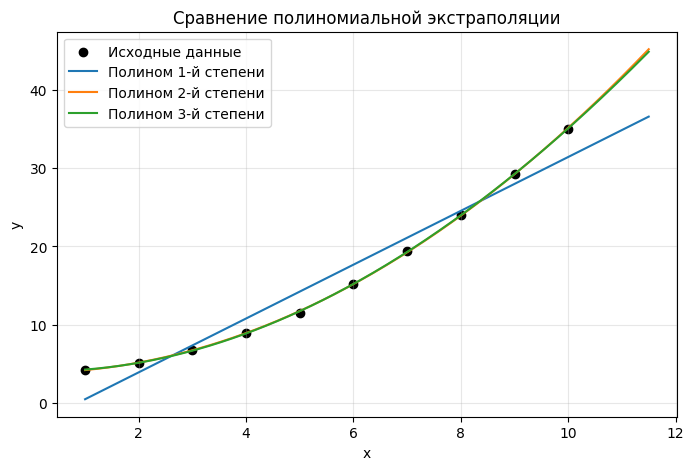

Степень 1: MSE = 5.1165, коэффициенты = [ 3.4467 -3.0067]
Степень 2: MSE = 0.0102, коэффициенты = [0.311  0.0258 3.835 ]
Степень 3: MSE = 0.0082, коэффициенты = [-2.500e-03  3.523e-01 -1.649e-01  4.050e+00]


In [4]:
x = np.arange(1, 11)
y = np.array([4.2, 5.1, 6.8, 8.9, 11.5, 15.2, 19.4, 24.0, 29.3, 35.1])

x_dense = np.linspace(x.min(), x.max() + 1.5, 300)
results = []

plt.scatter(x, y, color='black', label='Исходные данные')
for degree, color in zip([1, 2, 3], ['tab:blue', 'tab:orange', 'tab:green']):
    coeffs = np.polyfit(x, y, degree)
    poly = np.poly1d(coeffs)
    mse = mean_squared_error(y, poly(x))
    results.append({'Степень': degree, 'MSE': round(mse, 4), 'Коэффициенты': coeffs})
    plt.plot(x_dense, poly(x_dense), color=color, label=f'Полином {degree}-й степени')

plt.title('Сравнение полиномиальной экстраполяции')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

for item in results:
    print(f"Степень {item['Степень']}: MSE = {item['MSE']}, коэффициенты = {np.round(item['Коэффициенты'], 4)}")



## 1.1.5 Задание

Подставить собственные данные, поэкспериментировать с разными функциями и проанализировать динамику изменения данных.


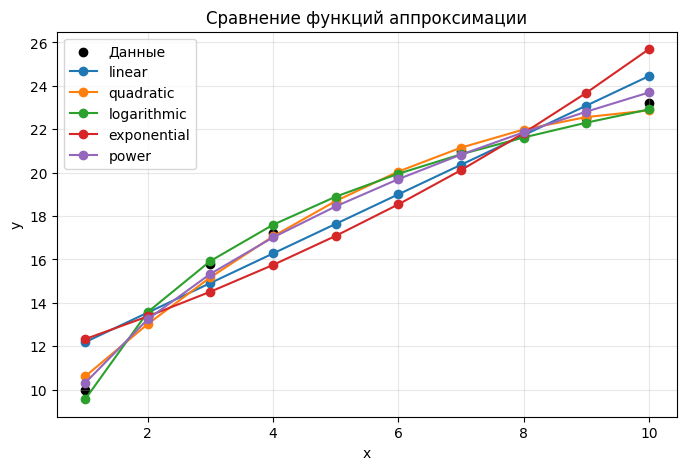

        Модель     MSE
2  logarithmic  0.0664
4        power  0.0792
1    quadratic  0.1210
0       linear  1.0332
3  exponential  2.1429
По минимальному MSE лучше всего описывает данные модель: logarithmic


In [5]:
x = np.arange(1, 11, dtype=float)
y = np.array([10.0, 13.4, 15.8, 17.2, 18.6, 19.8, 21.0, 21.7, 22.5, 23.2])

models = {}

lin_coeffs = np.polyfit(x, y, 1)
models['linear'] = np.poly1d(lin_coeffs)(x)

quad_coeffs = np.polyfit(x, y, 2)
models['quadratic'] = np.poly1d(quad_coeffs)(x)

log_coeffs = np.polyfit(np.log(x), y, 1)
models['logarithmic'] = log_coeffs[0] * np.log(x) + log_coeffs[1]

exp_coeffs = np.polyfit(x, np.log(y), 1)
models['exponential'] = np.exp(exp_coeffs[1]) * np.exp(exp_coeffs[0] * x)

power_coeffs = np.polyfit(np.log(x), np.log(y), 1)
models['power'] = np.exp(power_coeffs[1]) * x ** power_coeffs[0]

summary = []
plt.scatter(x, y, color='black', label='Данные')
for name, prediction in models.items():
    mse = mean_squared_error(y, prediction)
    summary.append({'Модель': name, 'MSE': round(mse, 4)})
    plt.plot(x, prediction, marker='o', label=name)

plt.title('Сравнение функций аппроксимации')
plt.xlabel('x')
plt.ylabel('y')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

summary_df = pd.DataFrame(summary).sort_values('MSE')
print(summary_df)
best_model = summary_df.iloc[0]['Модель']
print(f'По минимальному MSE лучше всего описывает данные модель: {best_model}')



## 1.2.1 Задание

Построить модель линейной регрессии для данных о зависимости заработной платы от опыта работы, найти коэффициенты и построить прогноз.


Коэффициент наклона: 9423.82
Свободный член: 25321.58
R^2 на тестовой выборке: 0.9024
   YearsExperience  PredictedSalary
0              1.5         39457.31
1              3.0         53593.03
2              5.0         72440.66
3              7.5         96000.20
4             10.0        119559.74


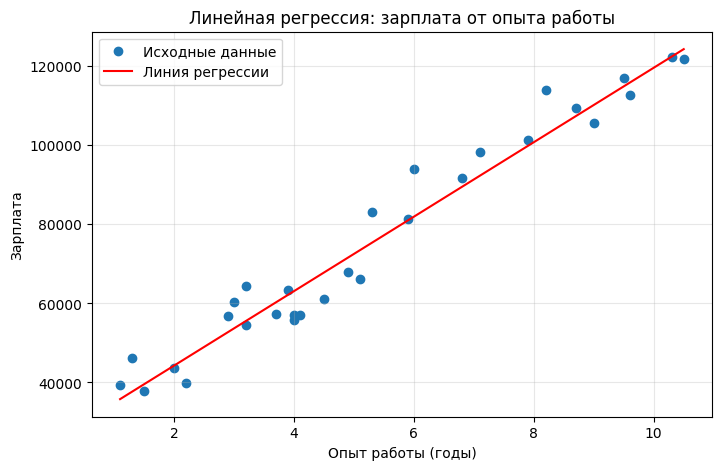

In [8]:
salary_path = '/Users/akarmain/Zed/vanilla_code/MIREA/trem_1/BigData/Workbook_4/Salary_Data.csv'
salary_df = pd.read_csv(salary_path)

X = salary_df[['YearsExperience']]
y = salary_df['Salary']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = LinearRegression()
model.fit(X_train, y_train)
predictions = model.predict(X_test)

print('Коэффициент наклона:', round(model.coef_[0], 2))
print('Свободный член:', round(model.intercept_, 2))
print('R^2 на тестовой выборке:', round(r2_score(y_test, predictions), 4))

forecast_years = pd.DataFrame({'YearsExperience': [1.5, 3, 5, 7.5, 10]})
forecast_salary = model.predict(forecast_years)
forecast_df = forecast_years.copy()
forecast_df['PredictedSalary'] = np.round(forecast_salary, 2)
print(forecast_df)

plt.scatter(X, y, label='Исходные данные')
plt.plot(X, model.predict(X), color='red', label='Линия регрессии')
plt.xlabel('Опыт работы (годы)')
plt.ylabel('Зарплата')
plt.title('Линейная регрессия: зарплата от опыта работы')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()



## 1.3 Задание

Построить модель множественной линейной регрессии для данных из нескольких столбцов, найти коэффициенты и построить прогноз.


In [10]:
petrol_path = '/Users/akarmain/Zed/vanilla_code/MIREA/trem_1/BigData/Workbook_4/petrol_consumption.csv'
petrol_df = pd.read_csv(petrol_path)

X = petrol_df.drop(columns=['Petrol_Consumption'])
y = petrol_df['Petrol_Consumption']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
multi_model = LinearRegression()
multi_model.fit(X_train, y_train)
multi_pred = multi_model.predict(X_test)

coef_df = pd.DataFrame({
    'Признак': X.columns,
    'Коэффициент': np.round(multi_model.coef_, 4),
})
print(coef_df)
print('Свободный член:', round(multi_model.intercept_, 4))
print('RMSE:', round(np.sqrt(mean_squared_error(y_test, multi_pred)), 4))
print('R^2:', round(r2_score(y_test, multi_pred), 4))

sample_state = X.mean().to_frame().T
forecast_value = multi_model.predict(sample_state)[0]
sample_state['Прогноз потребления'] = round(forecast_value, 2)
print(sample_state)


                        Признак  Коэффициент
0                    Petrol_tax     -36.9937
1                Average_income      -0.0565
2                Paved_Highways      -0.0044
3  Population_Driver_licence(%)    1346.8693
Свободный член: 361.4509
RMSE: 63.9004
R^2: 0.3914
   Petrol_tax  Average_income  Paved_Highways  Population_Driver_licence(%)  \
0    7.668333     4241.833333     5565.416667                      0.570333   

   Прогноз потребления  
0               581.73  



## Задание*

Реализация аппроксимации полиномами первой и второй степени для вариантов из тетради. По умолчанию выбран `VARIANT = 1`, его можно изменить.


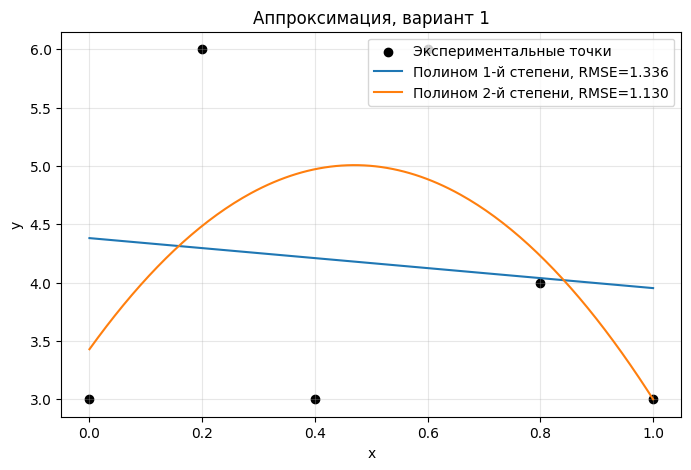

Коэффициенты полинома 1-й степени: [-0.4286  4.381 ]
Коэффициенты полинома 2-й степени: [-7.1429  6.7143  3.4286]
RMSE для 1-й степени: 1.3357
RMSE для 2-й степени: 1.1297


In [11]:
variants = {
    1: {'x': [0.0, 0.2, 0.4, 0.6, 0.8, 1.0], 'y': [3.0, 6.0, 3.0, 6.0, 4.0, 3.0]},
    2: {'x': [0.0, 0.2, 0.4, 0.6, 0.8, 1.0], 'y': [5.0, 5.0, 4.0, 4.0, 6.0, 6.0]},
    3: {'x': [3.0, 3.2, 3.4, 3.6, 3.8, 4.0], 'y': [2.0, 3.0, 3.0, 3.0, 2.0, 4.0]},
    4: {'x': [3.0, 3.2, 3.4, 3.6, 3.8, 4.0], 'y': [6.0, 2.0, 6.0, 4.0, 3.0, 4.0]},
    5: {'x': [5.0, 5.2, 5.4, 5.6, 5.8, 6.0], 'y': [2.0, 4.0, 4.0, 3.0, 3.0, 3.0]},
    6: {'x': [4.0, 4.2, 4.4, 4.6, 4.8, 5.0], 'y': [4.0, 3.0, 6.0, 6.0, 4.0, 4.0]},
    7: {'x': [1.0, 1.2, 1.4, 1.6, 1.8, 2.0], 'y': [2.0, 6.0, 4.0, 4.0, 2.0, 5.0]},
    8: {'x': [5.0, 5.2, 5.4, 5.6, 5.8, 6.0], 'y': [3.0, 2.0, 5.0, 2.0, 2.0, 3.0]},
    9: {'x': [2.0, 2.2, 2.4, 2.6, 2.8, 3.0], 'y': [4.0, 2.0, 4.0, 2.0, 5.0, 2.0]},
    10: {'x': [0.0, 0.2, 0.4, 0.6, 0.8, 1.0], 'y': [6.0, 3.0, 2.0, 6.0, 2.0, 5.0]},
}

VARIANT = 1
data = variants[VARIANT]
x = np.array(data['x'])
y = np.array(data['y'])

poly1 = np.poly1d(np.polyfit(x, y, 1))
poly2 = np.poly1d(np.polyfit(x, y, 2))
rmse1 = np.sqrt(mean_squared_error(y, poly1(x)))
rmse2 = np.sqrt(mean_squared_error(y, poly2(x)))

x_dense = np.linspace(x.min(), x.max(), 200)
plt.scatter(x, y, color='black', label='Экспериментальные точки')
plt.plot(x_dense, poly1(x_dense), label=f'Полином 1-й степени, RMSE={rmse1:.3f}')
plt.plot(x_dense, poly2(x_dense), label=f'Полином 2-й степени, RMSE={rmse2:.3f}')
plt.title(f'Аппроксимация, вариант {VARIANT}')
plt.xlabel('x')
plt.ylabel('y')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

print('Коэффициенты полинома 1-й степени:', np.round(poly1.coefficients, 4))
print('Коэффициенты полинома 2-й степени:', np.round(poly2.coefficients, 4))
print('RMSE для 1-й степени:', round(rmse1, 4))
print('RMSE для 2-й степени:', round(rmse2, 4))
